Probability of Method A meeting the threshold: 0.8337
Probability of Method B meeting the threshold: 0.8561


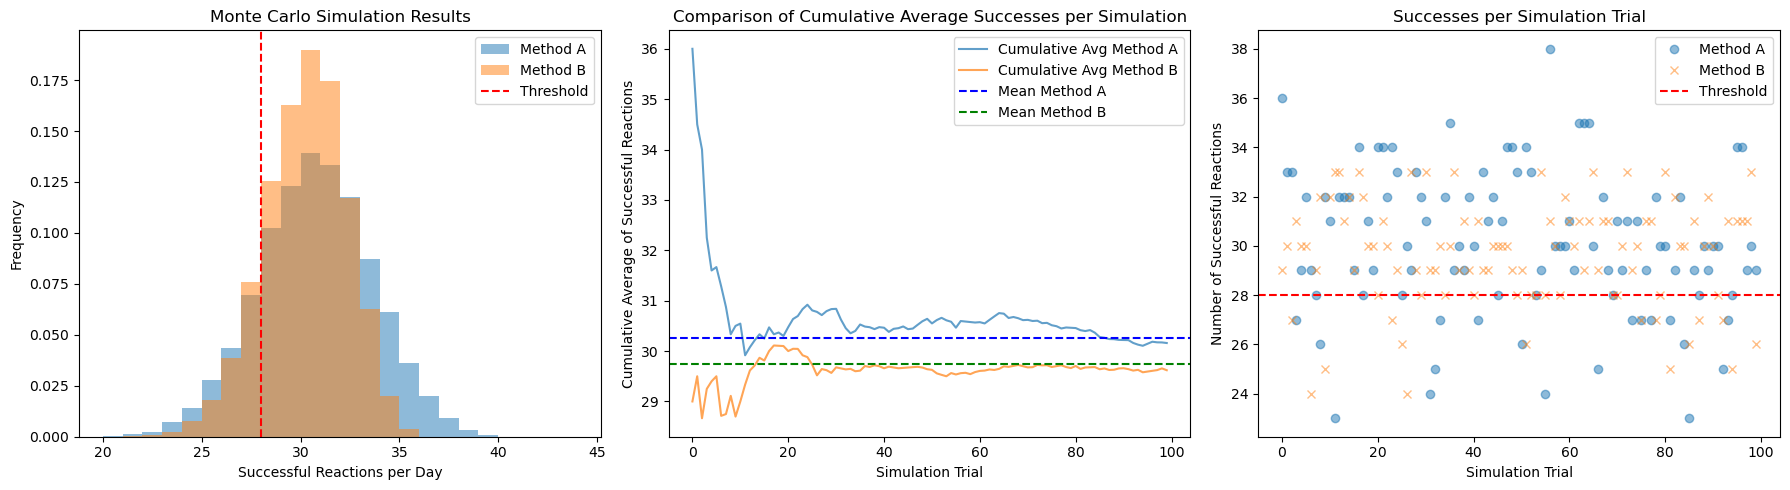

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_simulation(success_rate, time_per_operation, total_time, trials=10000, threshold=28):
    operations_per_day = total_time // time_per_operation
    successes = np.random.binomial(n=operations_per_day, p=success_rate, size=trials)
    probability_of_meeting_threshold = np.mean(successes >= threshold)
    return probability_of_meeting_threshold, successes

# Parameters
total_time = 7 * 60  # 7 hours converted to minutes
success_rate_A = 0.72
time_per_operation_A = 10
success_rate_B = 0.85
time_per_operation_B = 12
trials = 10000

# Run simulations
prob_A, successes_A = monte_carlo_simulation(success_rate_A, time_per_operation_A, total_time, trials)
prob_B, successes_B = monte_carlo_simulation(success_rate_B, time_per_operation_B, total_time, trials)

# Display results
print(f"Probability of Method A meeting the threshold: {prob_A:.4f}")
print(f"Probability of Method B meeting the threshold: {prob_B:.4f}")

# Visualization
plt.figure(figsize=(18, 5))

# Histogram of successes
plt.subplot(1, 3, 1)
plt.hist(successes_A, bins=range(20, 45), alpha=0.5, label='Method A', density=True)
plt.hist(successes_B, bins=range(20, 45), alpha=0.5, label='Method B', density=True)
plt.axvline(28, color='r', linestyle='dashed', label='Threshold')
plt.xlabel('Successful Reactions per Day')
plt.ylabel('Frequency')
plt.legend()
plt.title('Monte Carlo Simulation Results')

# Cumulative average of successes
cumulative_avg_A = np.cumsum(successes_A[:100]) / np.arange(1, 101)
cumulative_avg_B = np.cumsum(successes_B[:100]) / np.arange(1, 101)
mean_A = np.mean(successes_A)
mean_B = np.mean(successes_B)

plt.subplot(1, 3, 2)
plt.plot(cumulative_avg_A, label='Cumulative Avg Method A', linestyle='-', alpha=0.7)
plt.plot(cumulative_avg_B, label='Cumulative Avg Method B', linestyle='-', alpha=0.7)
plt.axhline(mean_A, color='b', linestyle='dashed', label='Mean Method A')
plt.axhline(mean_B, color='g', linestyle='dashed', label='Mean Method B')
plt.xlabel('Simulation Trial')
plt.ylabel('Cumulative Average of Successful Reactions')
plt.legend()
plt.title('Comparison of Cumulative Average Successes per Simulation')

# Scatter plot of individual successes per simulation trial
plt.subplot(1, 3, 3)
plt.plot(successes_A[:100], label='Method A', marker='o', linestyle='', alpha=0.5)
plt.plot(successes_B[:100], label='Method B', marker='x', linestyle='', alpha=0.5)
plt.axhline(28, color='r', linestyle='dashed', label='Threshold')
plt.xlabel('Simulation Trial')
plt.ylabel('Number of Successful Reactions')
plt.legend()
plt.title('Successes per Simulation Trial')

plt.tight_layout()
plt.show()
